# Analyse de la vitesse et de la direction

## Description

La vitesse est calculee a partir des deplacements entre centres successifs: `distance = sqrt(dx^2 + dy^2)`. Elle est exprimee en pixels/frame. La direction est calculee avec `atan2(dy, dx)`. Dans le repere image, l'axe y augmente vers le bas, ce qui doit etre garde en tete pour l'interpretation.


Frames chargees: 1661
Bbox manuelle utilisee dans les notebooks: (535, 300, 220, 105)


,frame,x,y,dx,dy,speed_px_per_frame,direction_deg
0,0,641.0,359.5,0.000000,0.000000,0.000000,0.000000
1,1,641.0,359.5,0.321840,-0.089877,0.334154,-15.602901
2,2,641.0,359.5,-0.321149,-0.177551,0.366962,-151.063412
3,3,640.0,367.0,-0.672940,-0.094154,0.679495,-172.035191
4,4,640.0,367.0,0.447496,-0.172917,0.479743,-21.127042
5,5,639.0,367.0,-0.822501,-0.201960,0.846933,-166.204327
6,6,638.0,367.0,-0.551371,-0.055490,0.554156,-174.253104
7,7,638.0,367.0,0.002912,-0.024324,0.024497,-83.174025
8,8,637.0,367.0,-0.779614,-0.250670,0.818922,-162.175777
9,9,636.0,367.0,-0.603849,-0.076950,0.608732,-172.737789


Vitesse moyenne: 0.48 pixels/frame
Vitesse maximale: 1.20 pixels/frame
Direction moyenne: -1.48 degres


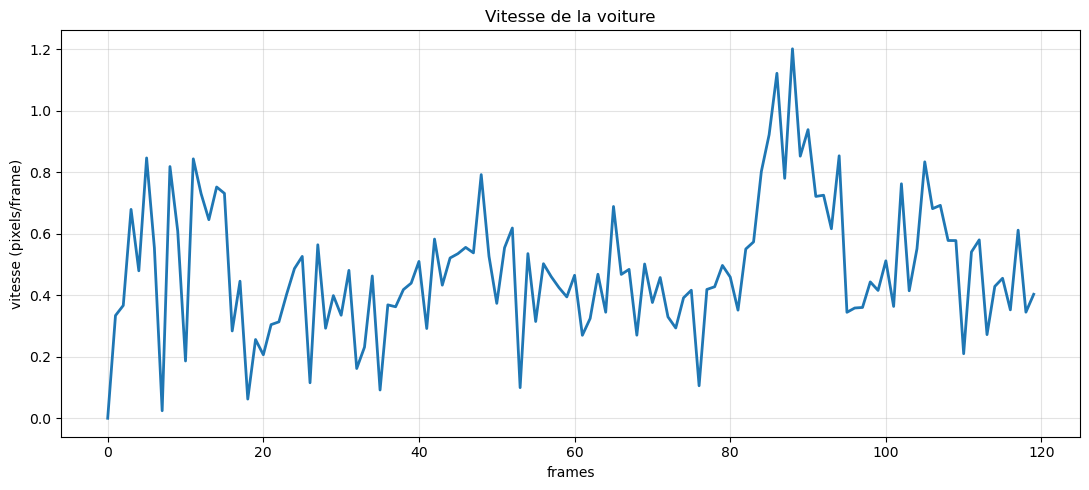

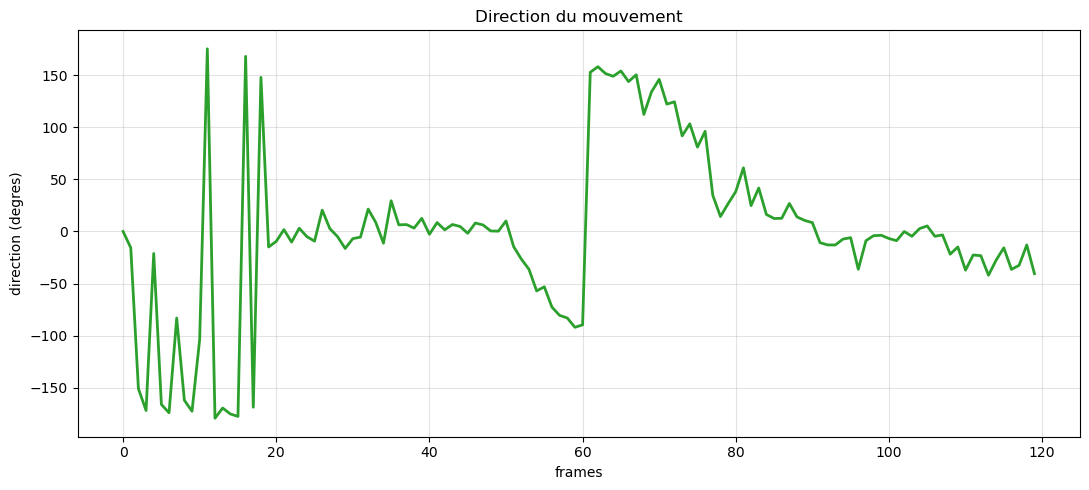

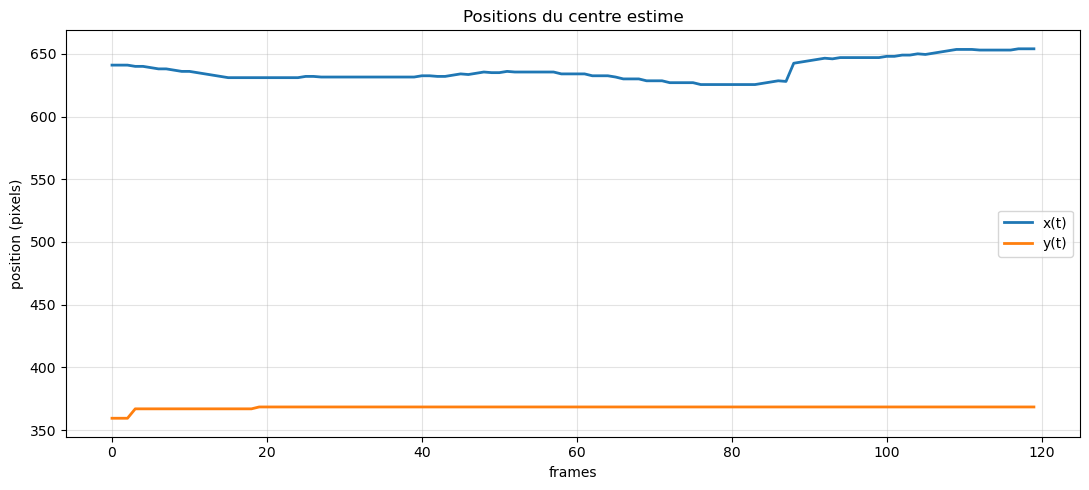

Graphe vitesse sauvegarde: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\results\graphs\speed_over_time.png
Graphe direction sauvegarde: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\results\graphs\direction_over_time.png
Graphe positions sauvegarde: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\results\graphs\positions_over_time.png


In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / "data" / "car" / "car-11" / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted([p for p in DATASET_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}])
if not image_files:
    raise RuntimeError("Aucune image trouvee dans data/car/car-11/img/.")

initial_bbox = (535, 300, 220, 105)  # bbox manuelle: x, y, w, h

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_bgr(image, title, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr_to_rgb(image))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(image, title, figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_saved_image(path, title=None, figsize=(12, 6), is_gray=False):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE if is_gray else cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"Image illisible: {path}")
    if is_gray:
        show_gray(image, title or path.name, figsize=figsize)
    else:
        show_bgr(image, title or path.name, figsize=figsize)
    return image

def save_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def save_gray(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

print(f"Frames chargees: {len(image_files)}")
print(f"Bbox manuelle utilisee dans les notebooks: {initial_bbox}")

def ensure_tracking_table():
    trajectory_path = RESULTS_DIR / "trajectory.csv"
    if not trajectory_path.exists():
        raise FileNotFoundError("results/trajectory.csv est introuvable. Lancez d'abord le pipeline principal pour produire les resultats.")
    df = pd.read_csv(trajectory_path)
    required = {"frame", "x", "y", "dx", "dy", "speed_px_per_frame", "direction_deg"}
    missing = required.difference(df.columns)
    if missing:
        raise RuntimeError(f"Colonnes manquantes dans trajectory.csv: {missing}")
    return df

def make_trajectory_overlay(df, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    frame_index = int(df["frame"].iloc[min(len(df) // 2, len(df) - 1)])
    frame_index = max(0, min(frame_index, len(image_files) - 1))
    background = cv2.imread(str(image_files[frame_index]))
    if background is None:
        background = cv2.imread(str(image_files[0]))
    overlay = background.copy()
    points = df[["x", "y"]].dropna().to_numpy(dtype=np.int32)
    if len(points) == 0:
        raise RuntimeError("Aucun centre disponible pour dessiner la trajectoire.")
    for i in range(1, len(points)):
        cv2.line(overlay, tuple(points[i - 1]), tuple(points[i]), (0, 0, 255), 2)
    step = max(1, len(points) // 180)
    for point in points[::step]:
        cv2.circle(overlay, tuple(point), 3, (255, 0, 0), -1)
    start = tuple(points[0])
    end = tuple(points[-1])
    cv2.circle(overlay, start, 9, (0, 255, 0), -1)
    cv2.circle(overlay, end, 9, (0, 255, 255), -1)
    cv2.putText(overlay, "Depart", (start[0] + 10, start[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)
    cv2.putText(overlay, "Arrivee", (end[0] + 10, end[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(overlay, "Trajectoire globale estimee de la voiture", (30, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 3, cv2.LINE_AA)
    cv2.imwrite(str(output_path), overlay)
    return output_path, overlay

def make_speed_direction_graphs(df):
    graphs_dir = ensure_dir(RESULTS_DIR / "graphs")
    speed_path = graphs_dir / "speed_over_time.png"
    direction_path = graphs_dir / "direction_over_time.png"
    pos_path = graphs_dir / "positions_over_time.png"

    plt.figure(figsize=(11, 5))
    plt.plot(df["frame"], df["speed_px_per_frame"], color="tab:blue", linewidth=2)
    plt.title("Vitesse de la voiture")
    plt.xlabel("frames")
    plt.ylabel("vitesse (pixels/frame)")
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.savefig(speed_path, dpi=150)
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(df["frame"], df["direction_deg"], color="tab:green", linewidth=2)
    plt.title("Direction du mouvement")
    plt.xlabel("frames")
    plt.ylabel("direction (degres)")
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.savefig(direction_path, dpi=150)
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(df["frame"], df["x"], label="x(t)", linewidth=2)
    plt.plot(df["frame"], df["y"], label="y(t)", linewidth=2)
    plt.title("Positions du centre estime")
    plt.xlabel("frames")
    plt.ylabel("position (pixels)")
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.savefig(pos_path, dpi=150)
    plt.show()
    return speed_path, direction_path, pos_path

df = ensure_tracking_table()
columns = ["frame", "x", "y", "dx", "dy", "speed_px_per_frame", "direction_deg"]
display(df[columns].head(15))

mean_speed = df["speed_px_per_frame"].mean()
max_speed = df["speed_px_per_frame"].max()
mean_direction = df["direction_deg"].iloc[1:].mean() if len(df) > 1 else 0.0
print(f"Vitesse moyenne: {mean_speed:.2f} pixels/frame")
print(f"Vitesse maximale: {max_speed:.2f} pixels/frame")
print(f"Direction moyenne: {mean_direction:.2f} degres")

speed_path, direction_path, pos_path = make_speed_direction_graphs(df)
print("Graphe vitesse sauvegarde:", speed_path)
print("Graphe direction sauvegarde:", direction_path)
print("Graphe positions sauvegarde:", pos_path)


## Interpretation

La vitesse est calculee comme la distance entre deux centres successifs. Elle est exprimee en pixels/frame car aucune conversion metrique n'est utilisee ici. La vitesse moyenne resume l'intensite generale du mouvement, tandis que la vitesse maximale signale les frames ou le deplacement estime est le plus fort. La direction est calculee avec `atan2(dy, dx)`. Elle decrit l'orientation du mouvement dans le plan image, en tenant compte du repere image. Des variations brusques peuvent indiquer une perte de points, une segmentation imparfaite ou un changement local d'apparence.


## Resume de l'etape

Les graphes de vitesse et de direction fournissent une analyse quantitative du mouvement de la voiture. Ils completent la trajectoire globale en decrivant comment le deplacement evolue au cours du temps.
